In [1]:
import gc
import torch

# 先尽量释放上一轮 notebook 残留的显存占用。
# 这不会删除你磁盘上的内容，只是清理 Python / PyTorch 当前进程里的缓存。
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    print('GPU cache cleared.')
else:
    print('CUDA not available, skip GPU cache clear.')


GPU cache cleared.


# 下一部分：Policy Gradient / REINFORCE

前面我们一直在学 `Q-learning / DQN` 这一条路线，也就是值函数方法。

这一课开始，我们正式进入另一条非常重要的主线：`Policy Gradient`。

这节课会用最经典的 `REINFORCE` 来入门，你会第一次看到：

- 不再先学 `Q(s, a)`
- 而是直接学习“在某个状态下该怎么选动作”的策略本身


## 1. 值函数方法和策略方法的区别

前面的 DQN 路线大致是这样：
- 先估计每个动作的价值 `Q(s, a)`
- 然后选择价值最大的动作

而 `Policy Gradient` 的思路不一样：
- 直接让网络输出动作概率
- 直接优化这个策略

也就是说，网络不再回答“哪个动作值多少”，而是回答：

**“在这个状态下，我应该以多大概率选每个动作？”**


## 2. REINFORCE 是什么

`REINFORCE` 是最经典、最基础的策略梯度算法之一。

它的核心思想很直观：
- 一整轮 episode 跑完以后
- 回头看哪些动作最后带来了高回报
- 就提高这些动作在当时状态下被选中的概率

如果某些动作最后带来的总回报更差，就降低它们的概率。

所以你可以把 REINFORCE 理解成：

**用“最后整轮的回报”来反过来奖励整条动作轨迹。**


In [2]:
import random
import warnings

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


In [3]:
def pick_device():
    if torch.cuda.is_available():
        try:
            _ = torch.zeros(1, device='cuda')
            return torch.device('cuda')
        except Exception as e:
            warnings.warn(f'检测到 CUDA，但当前环境无法真正使用 GPU，已回退到 CPU。原因: {e}')
    return torch.device('cpu')


device = pick_device()
print('当前设备:', device)
if torch.cuda.is_available():
    print('检测到 CUDA 设备:', torch.cuda.get_device_name(0))


当前设备: cuda
检测到 CUDA 设备: NVIDIA GeForce RTX 5090


In [4]:
env = gym.make('CartPole-v1')
state, info = env.reset(seed=42)
print('初始状态:', state)
print('状态维度:', env.observation_space.shape[0])
print('动作数量:', env.action_space.n)


初始状态: [ 0.027 -0.006  0.036  0.02 ]
状态维度: 4
动作数量: 2


## 3. 策略网络长什么样

这次网络的输出不再是 Q 值，而是动作的 logits。

经过 softmax 后，就会变成一个概率分布：
- 选左的概率
- 选右的概率

然后我们按照这个概率分布采样动作。


In [5]:
def to_tensor(x, device):
    return torch.tensor(x, dtype=torch.float32, device=device)


class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x):
        return self.net(x)


## 4. 回报 Return 怎么算

REINFORCE 不是一步一步立刻更新，而是先跑完整个 episode。

然后对轨迹里的每一步，计算它从那一刻往后能拿到的折扣累计回报：

$G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + ...$

这个 `G_t` 就是那一步动作的“事后成绩单”。


In [6]:
def compute_returns(rewards, gamma=0.99):
    returns = []
    G = 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)

    returns = torch.tensor(returns, dtype=torch.float32)

    # 做标准化可以让训练更稳定。
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    return returns


## 5. 训练 REINFORCE

这节课最重要的主线是：

1. 用策略网络输出动作概率
2. 按概率采样动作并跑完整个 episode
3. 记录每一步动作对应的 `log_prob`
4. episode 结束后计算每一步的 return
5. 用 `-log_prob * return` 构造 loss

你可以把它理解成：

- 回报高的动作，增加它再次出现的概率
- 回报差的动作，降低它再次出现的概率


In [7]:
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

policy_net = PolicyNetwork(state_dim, action_dim, hidden_dim=128).to(device)
optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)

gamma = 0.99
episodes = 400
max_steps = 500

episode_rewards = []
loss_history = []

for episode in range(episodes):
    state, info = env.reset()
    log_probs = []
    rewards = []
    total_reward = 0.0

    for step in range(max_steps):
        state_tensor = to_tensor(state, device).unsqueeze(0)

        # 策略网络输出 logits，再交给 Categorical 形成动作分布
        logits = policy_net(state_tensor)
        dist = Categorical(logits=logits)

        # 这次不是 argmax，而是按概率采样动作
        action = dist.sample()
        log_prob = dist.log_prob(action)

        next_state, reward, terminated, truncated, info = env.step(int(action.item()))
        done = terminated or truncated

        log_probs.append(log_prob)
        rewards.append(reward)
        total_reward += reward
        state = next_state

        if done:
            break

    returns = compute_returns(rewards, gamma=gamma).to(device)

    # REINFORCE 的核心 loss：
    # 如果某一步最后对应的 return 更高，就会鼓励当时那个动作的概率上升。
    policy_loss = []
    for log_prob, G in zip(log_probs, returns):
        policy_loss.append(-log_prob * G)

    loss = torch.stack(policy_loss).sum()

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=10.0)
    optimizer.step()

    episode_rewards.append(total_reward)
    loss_history.append(float(loss.item()))

print('训练完成。')
print('最后 20 轮平均 reward:', round(float(np.mean(episode_rewards[-20:])), 2))


训练完成。
最后 20 轮平均 reward: 241.9


## 6. 看训练曲线

这节课你会发现，Policy Gradient 的曲线通常比 DQN 更抖一些。

这是很正常的，因为它直接在优化策略本身，方差往往比较大。
这也是为什么后面我们通常会继续学 baseline、Actor-Critic 等方法来降方差。


C:\Users\80740\AppData\Local\Temp\ipykernel_4564\3163183408.py:18: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_4564\3163183408.py:18: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_4564\3163183408.py:18: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_4564\3163183408.py:18: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_4564\3163183408.py:18: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_4564\3163183408.py:18: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missi

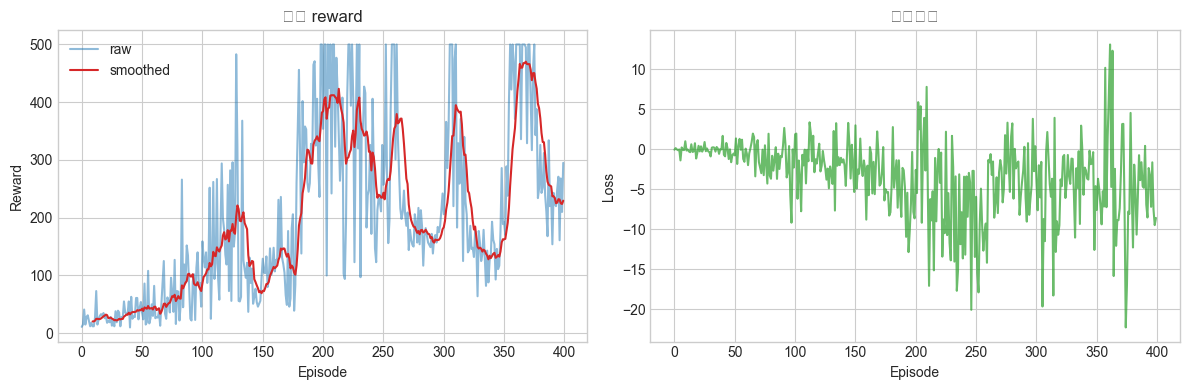

In [8]:
window = 10
smoothed_rewards = np.convolve(episode_rewards, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(episode_rewards, color='#1f77b4', alpha=0.5, label='raw')
axes[0].plot(range(window - 1, len(episode_rewards)), smoothed_rewards, color='#d62728', label='smoothed')
axes[0].set_title('每轮 reward')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward')
axes[0].legend()

axes[1].plot(loss_history, color='#2ca02c', alpha=0.7)
axes[1].set_title('训练损失')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.show()


## 7. 多次测试平均表现

训练好后，我们继续测 5 次，看平均 reward。
注意这里测试时就不再采样了，而是直接选概率最大的动作，方便观察策略表现。


In [9]:
test_env = gym.make('CartPole-v1')
test_rewards = []

policy_net.eval()
with torch.no_grad():
    for episode_idx in range(5):
        state, info = test_env.reset(seed=123 + episode_idx)
        test_reward = 0.0

        for step in range(500):
            state_tensor = to_tensor(state, device).unsqueeze(0)
            logits = policy_net(state_tensor)
            action = int(torch.argmax(logits, dim=1).item())

            state, reward, terminated, truncated, info = test_env.step(action)
            test_reward += reward
            if terminated or truncated:
                break

        test_rewards.append(test_reward)

print('测试 rewards:', test_rewards)
print('测试平均 reward:', round(float(np.mean(test_rewards)), 2))
test_env.close()


测试 rewards: [211.0, 256.0, 227.0, 195.0, 212.0]
测试平均 reward: 220.2


## 8. 这节课最应该记住什么

如果你想抓住这节课的本质，就记住这句话：

**REINFORCE 不再先学动作价值，而是直接学动作概率，并用整条轨迹的回报去调整策略。**

这就是从“值函数方法”走向“策略方法”的真正切换。


## 9. 下一课最自然学什么

REINFORCE 最大的问题是方差比较大，训练不太稳。

所以学完这节后，最自然的下一步就是：
- `REINFORCE + baseline`
- 或直接进入 `Actor-Critic`

如果按学习路线来说，我最推荐你下一课先上 `REINFORCE with Baseline`。
